In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# P5 - Multiple metrics and variants

## 1. What goes wrong
Check twenty metrics and ship if any is significant. Even with no real effect, one usually will be.

## 2. Simulate

In [2]:
from abtest.pitfalls import multiple_testing as mt
mm = mt.fpr_vs_metrics(n_sims=20_000)
mm.round(3)

,n_metrics,uncorrected,holm,bh
0,1,0.048,0.048,0.048
1,2,0.098,0.049,0.050
2,3,0.135,0.049,0.050
3,5,0.213,0.047,0.049
4,10,0.350,0.045,0.047
5,20,0.543,0.045,0.048
6,50,0.807,0.045,0.048


## 3. Quantify the damage

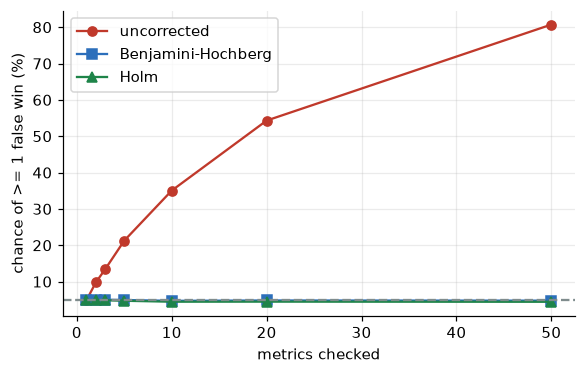

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(mm.n_metrics, mm.uncorrected * 100, 'o-', color=BAD, label='uncorrected'); ax.plot(mm.n_metrics, mm.bh * 100, 's-', color=ACCENT, label='Benjamini-Hochberg'); ax.plot(mm.n_metrics, mm.holm * 100, '^-', color=GOOD, label='Holm'); ax.axhline(5, color=NEUTRAL, ls='--'); ax.legend(); ax.set(xlabel='metrics checked', ylabel='chance of >= 1 false win (%)'); plt.show()

## 4. Detect

Count the comparisons the team made. If the primary metric is significant raw but not after Holm, flag it (health checker: **Multiple testing**).

## 5. Fix

Pre-register **one** primary metric. Correct the rest: **Holm** controls the family-wise error rate (use it for decision metrics); **Benjamini-Hochberg** controls the false discovery rate (use it for exploratory metrics). The same applies to A/B/C/D variants that all share one control.

## 6. Verify the fix

In [4]:
print(mt.multiple_variants(n_sims=20_000).round(3).to_string(index=False))

 n_variants  uncorrected  holm
          2        0.048 0.048
          3        0.094 0.048
          5        0.156 0.043
          8        0.231 0.039


## So what
With 20 metrics the chance of a false win was over half. Holm and BH bring it back to about 5% with correlated metrics too.